In [26]:
import pandas as pd
import torch
import torch.nn as nn
import numpy as np
import matplotlib.pyplot as plt

In [27]:
path='binary_classification_data2.csv'

In [28]:
data=pd.read_csv(path)
data.head(6)

,X1,X2,label
0,0.754246,0.231481,1
1,-0.756159,0.153259,1
2,-0.815392,0.173282,1
3,-0.393731,0.692883,1
4,0.442208,-0.896723,0
5,-0.479646,0.676435,1


In [29]:
X = data[['X1', 'X2']].values #combining data
Y = data['label'].values

In [30]:
## Turn data into tensors
X=torch.tensor(X)
Y=torch.tensor(Y)

In [31]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X,Y,test_size=0.2,
                                                    random_state=42)



In [32]:
#making device agnostic code:
device = "cuda" if torch.cuda.is_available() else "cpu"
device

'cpu'

In [33]:
# Build model with non-linear activation function
from torch import nn
class ModelV2(nn.Module):
    def __init__(self):
        super().__init__()
        self.layer_1 = nn.Linear(in_features=2, out_features=10)
        self.layer_2 = nn.Linear(in_features=10, out_features=10)
        self.layer_3 = nn.Linear(in_features=10, out_features=1)
        self.relu = nn.ReLU() # <- add in ReLU activation function
        # Can also put sigmoid in the model
        # This would mean you don't need to use it on the predictions
        # self.sigmoid = nn.Sigmoid()

    def forward(self, x):
      # Intersperse the ReLU activation function between layers
       return self.layer_3(self.relu(self.layer_2(self.relu(self.layer_1(x)))))

model_2 = ModelV2().to(device)
print(model_2)

ModelV2(
  (layer_1): Linear(in_features=2, out_features=10, bias=True)
  (layer_2): Linear(in_features=10, out_features=10, bias=True)
  (layer_3): Linear(in_features=10, out_features=1, bias=True)
  (relu): ReLU()
)


![Neural Network](download.png)

In [34]:
# 1. Setup settings
model = model_2
epochs = 800
train_loss_history = []
test_loss_history = []

# 2. Define Loss and Optimizer
loss_fn = nn.BCEWithLogitsLoss()
optimizer = torch.optim.SGD(params=model.parameters(), lr=0.1)

In [35]:
# Convert your data to the correct PyTorch data types
X_train = X_train.float()
X_test = X_test.float()
y_train = y_train.float()  # Use .float() for BCEWithLogitsLoss
y_test = y_test.float()

# 3. The Core Training and Testing Loop
for epoch in range(epochs):
    ### Training Mode
    model.train()
    y_logits = model(X_train).squeeze() # Get raw network outputs
    loss = loss_fn(y_logits, y_train)   # Calculate training loss

    optimizer.zero_grad()               # Clear old gradients
    loss.backward()                     # Backpropagation
    optimizer.step()                    # Update model weights


    ### Testing Mode
    model.eval()
    with torch.inference_mode():
        test_logits = model(X_test).squeeze()
        test_loss = loss_fn(test_logits, y_test)
        train_loss_history.append(loss.item())
        test_loss_history.append(test_loss.item())

    # Print progress every 10 epochs
    if epoch % 10 == 0 or epoch == epochs - 1:
        print(f"Epoch: {epoch} | Train Loss: {loss:.5f} | Test Loss: {test_loss:.5f}")

Epoch: 0 | Train Loss: 0.71432 | Test Loss: 0.71458
Epoch: 10 | Train Loss: 0.70325 | Test Loss: 0.70417
Epoch: 20 | Train Loss: 0.69832 | Test Loss: 0.69947
Epoch: 30 | Train Loss: 0.69593 | Test Loss: 0.69717
Epoch: 40 | Train Loss: 0.69471 | Test Loss: 0.69599
Epoch: 50 | Train Loss: 0.69405 | Test Loss: 0.69534
Epoch: 60 | Train Loss: 0.69365 | Test Loss: 0.69495
Epoch: 70 | Train Loss: 0.69339 | Test Loss: 0.69469
Epoch: 80 | Train Loss: 0.69320 | Test Loss: 0.69450
Epoch: 90 | Train Loss: 0.69303 | Test Loss: 0.69435
Epoch: 100 | Train Loss: 0.69288 | Test Loss: 0.69422
Epoch: 110 | Train Loss: 0.69274 | Test Loss: 0.69410
Epoch: 120 | Train Loss: 0.69259 | Test Loss: 0.69399
Epoch: 130 | Train Loss: 0.69243 | Test Loss: 0.69388
Epoch: 140 | Train Loss: 0.69225 | Test Loss: 0.69374
Epoch: 150 | Train Loss: 0.69210 | Test Loss: 0.69363
Epoch: 160 | Train Loss: 0.69197 | Test Loss: 0.69355
Epoch: 170 | Train Loss: 0.69185 | Test Loss: 0.69348
Epoch: 180 | Train Loss: 0.69172 | Test

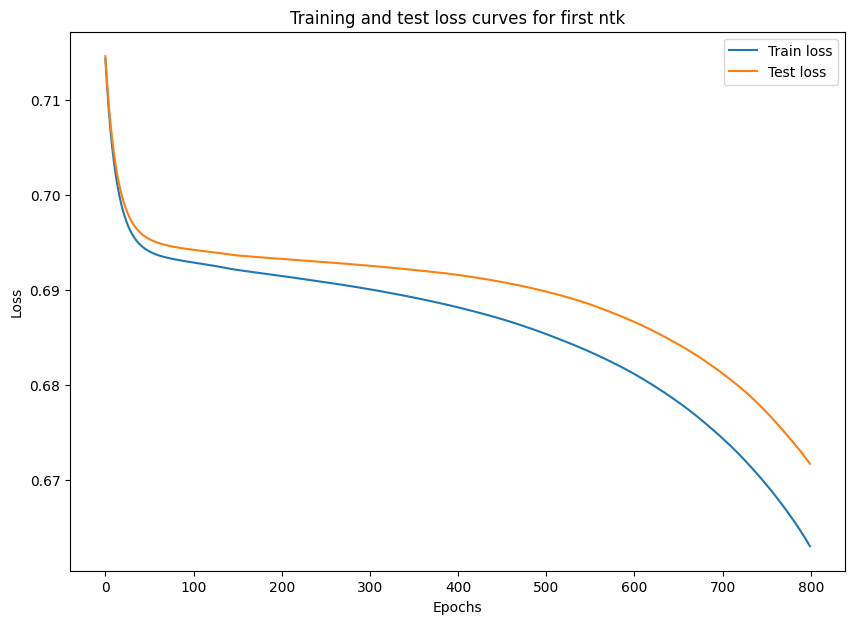

In [36]:
import matplotlib.pyplot as plt

# Since these are now standard Python lists of numbers over time,
# len() will work perfectly to map out your epochs!
epoch_count = list(range(len(train_loss_history)))

plt.figure(figsize=(10, 7))
plt.plot(epoch_count, train_loss_history, label="Train loss")
plt.plot(epoch_count, test_loss_history, label="Test loss")
plt.title("Training and test loss curves for first ntk")
plt.ylabel("Loss")
plt.xlabel("Epochs")
plt.legend()
plt.show()

In [37]:
# 4. Helper function to plot decision boundaries (Built right here!)
def local_plot_boundary(model, X, y):
    # Create a grid of points covering the data area
    x_min, x_max = X[:, 0].min() - 0.1, X[:, 0].max() + 0.1
    y_min, y_max = X[:, 1].min() - 0.1, X[:, 1].max() + 0.1
    xx, yy = np.meshgrid(np.linspace(x_min, x_max, 100), np.linspace(y_min, y_max, 100))

    # Predict the class for every point on the grid
    grid_points = torch.from_numpy(np.c_[xx.ravel(), yy.ravel()]).float()
    model.eval()
    with torch.inference_mode():
        preds = torch.sigmoid(model(grid_points)).round().numpy()

    # Plot the boundary colors and the actual data points
    plt.contourf(xx, yy, preds.reshape(xx.shape), alpha=0.7, cmap=plt.cm.RdYlBu)
    plt.scatter(X[:, 0], X[:, 1], c=y, s=40, cmap=plt.cm.RdYlBu, edgecolors="k")

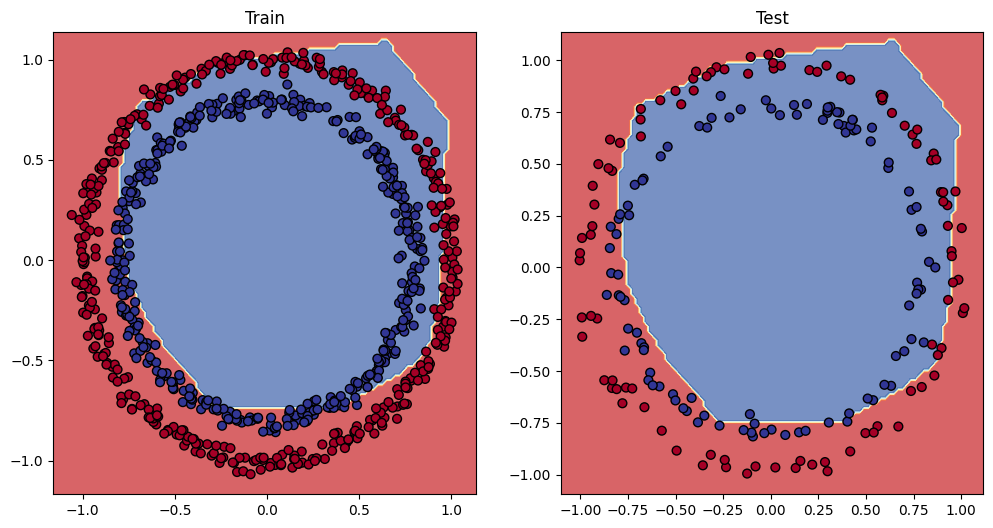

In [38]:
# 5. Plot the Results
plt.figure(figsize=(12, 6))

plt.subplot(1, 2, 1)
plt.title("Train")
local_plot_boundary(model, X_train, y_train)

plt.subplot(1, 2, 2)
plt.title("Test")
local_plot_boundary(model, X_test, y_test)

plt.show()

Model is underfitting so we need to add more layers or neurons

In [39]:
import torch.nn as nn

class ModelV2(nn.Module):
    def __init__(self):
        super().__init__()
        # Increasing out_features gives the model more "neurons" to think with
        self.layer_1 = nn.Linear(in_features=2, out_features=16) # Boosted to 16
        self.layer_2 = nn.Linear(in_features=16, out_features=16) # Boosted to 16
        self.layer_3 = nn.Linear(in_features=16, out_features=1)
        self.relu = nn.ReLU()

    def forward(self, x):
        # Pass data through layers and activate with ReLU to allow curves
        x = self.relu(self.layer_1(x))
        x = self.relu(self.layer_2(x))
        x = self.layer_3(x) # Output raw logits directly
        return x

# Instantiate the new model
model_3 = ModelV2()



In [40]:
# 1. Setup settings
model = model_3
epochs = 800
train_loss_history = []
test_loss_history = []

# 2. Define Loss and Optimizer
loss_fn = nn.BCEWithLogitsLoss()
optimizer = torch.optim.SGD(params=model.parameters(), lr=0.1)

In [41]:
# Convert your data to the correct PyTorch data types
X_train = X_train.float()
X_test = X_test.float()
y_train = y_train.float()  # Use .float() for BCEWithLogitsLoss
y_test = y_test.float()

# 3. The Core Training and Testing Loop
for epoch in range(epochs):
    ### Training Mode
    model.train()
    y_logits = model(X_train).squeeze() # Get raw network outputs
    loss = loss_fn(y_logits, y_train)   # Calculate training loss

    optimizer.zero_grad()               # Clear old gradients
    loss.backward()                     # Backpropagation
    optimizer.step()                    # Update model weights
    train_loss_history.append(loss.item())
    test_loss_history.append(test_loss.item())

    ### Testing Mode
    model.eval()
    with torch.inference_mode():
        test_logits = model(X_test).squeeze()
        test_loss = loss_fn(test_logits, y_test)

    # Print progress every 10 epochs
    if epoch % 10 == 0 or epoch == epochs - 1:
        print(f"Epoch: {epoch} | Train Loss: {loss:.5f} | Test Loss: {test_loss:.5f}")

Epoch: 0 | Train Loss: 0.69624 | Test Loss: 0.69616
Epoch: 10 | Train Loss: 0.69400 | Test Loss: 0.69425
Epoch: 20 | Train Loss: 0.69294 | Test Loss: 0.69340
Epoch: 30 | Train Loss: 0.69233 | Test Loss: 0.69294
Epoch: 40 | Train Loss: 0.69188 | Test Loss: 0.69263
Epoch: 50 | Train Loss: 0.69151 | Test Loss: 0.69239
Epoch: 60 | Train Loss: 0.69117 | Test Loss: 0.69218
Epoch: 70 | Train Loss: 0.69084 | Test Loss: 0.69200
Epoch: 80 | Train Loss: 0.69052 | Test Loss: 0.69182
Epoch: 90 | Train Loss: 0.69018 | Test Loss: 0.69162
Epoch: 100 | Train Loss: 0.68980 | Test Loss: 0.69139
Epoch: 110 | Train Loss: 0.68939 | Test Loss: 0.69114
Epoch: 120 | Train Loss: 0.68899 | Test Loss: 0.69091
Epoch: 130 | Train Loss: 0.68861 | Test Loss: 0.69069
Epoch: 140 | Train Loss: 0.68822 | Test Loss: 0.69048
Epoch: 150 | Train Loss: 0.68782 | Test Loss: 0.69027
Epoch: 160 | Train Loss: 0.68743 | Test Loss: 0.69007
Epoch: 170 | Train Loss: 0.68704 | Test Loss: 0.68989
Epoch: 180 | Train Loss: 0.68666 | Test

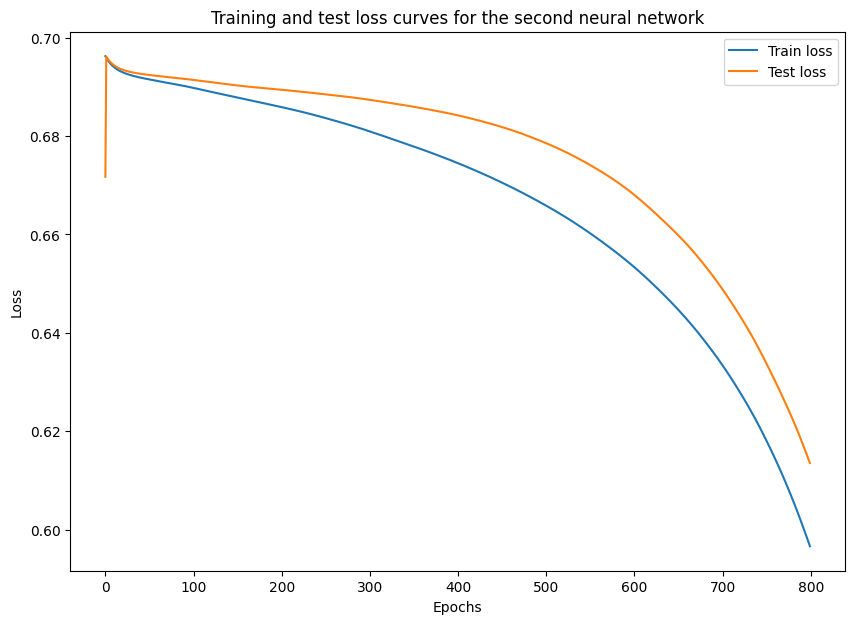

In [42]:
import matplotlib.pyplot as plt

# Since these are now standard Python lists of numbers over time,
# len() will work perfectly to map out your epochs!
epoch_count = list(range(len(train_loss_history)))

plt.figure(figsize=(10, 7))
plt.plot(epoch_count, train_loss_history, label="Train loss")
plt.plot(epoch_count, test_loss_history, label="Test loss")
plt.title("Training and test loss curves for the second neural network")
plt.ylabel("Loss")
plt.xlabel("Epochs")
plt.legend()
plt.show()

In [43]:
# 4. Helper function to plot decision boundaries (Built right here!)
def local_plot_boundary(model, X, y):
    # Create a grid of points covering the data area
    x_min, x_max = X[:, 0].min() - 0.1, X[:, 0].max() + 0.1
    y_min, y_max = X[:, 1].min() - 0.1, X[:, 1].max() + 0.1
    xx, yy = np.meshgrid(np.linspace(x_min, x_max, 100), np.linspace(y_min, y_max, 100))

    # Predict the class for every point on the grid
    grid_points = torch.from_numpy(np.c_[xx.ravel(), yy.ravel()]).float()
    model.eval()
    with torch.inference_mode():
        preds = torch.sigmoid(model(grid_points)).round().numpy()

    # Plot the boundary colors and the actual data points
    plt.contourf(xx, yy, preds.reshape(xx.shape), alpha=0.7, cmap=plt.cm.RdYlBu)
    plt.scatter(X[:, 0], X[:, 1], c=y, s=40, cmap=plt.cm.RdYlBu, edgecolors="k")

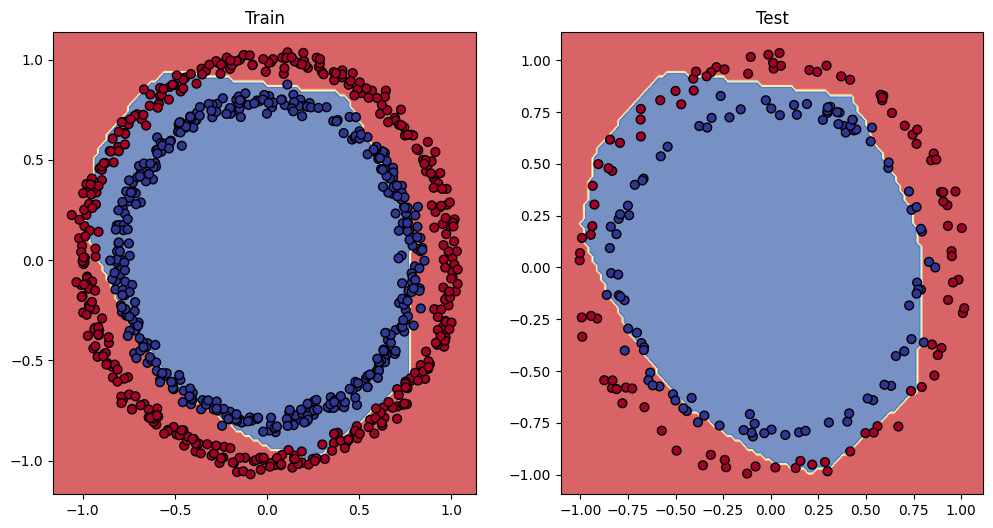

In [44]:
# 5. Plot the Results
plt.figure(figsize=(12, 6))

plt.subplot(1, 2, 1)
plt.title("Train")
local_plot_boundary(model, X_train, y_train)

plt.subplot(1, 2, 2)
plt.title("Test")
local_plot_boundary(model, X_test, y_test)

plt.show()